In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import statsmodels.api as sm

### Loading the data

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00560/SeoulBikeData.csv"
data = pd.read_csv(url,sep=',',encoding='unicode_escape')
data.replace(['Spring','Summer', 'Autumn','Winter'],[1,1,0,0], inplace=True)
data

/tmp/ipython-input-3532888852.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace(['Spring','Summer', 'Autumn','Winter'],[1,1,0,0], inplace=True)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,0,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,0,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,0,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,0,No Holiday,Yes


### Building the model

In [3]:
# Create a design matrix
design_matrix = data[['Rainfall(mm)','Seasons']].to_numpy()
design_matrix = np.append(design_matrix,np.ones((design_matrix.shape[0],1)),axis=1)

# extract DV
y = data[['Rented Bike Count']].to_numpy()

In [4]:
# Random linear combo for testing
lincombo = 1.5 * design_matrix[:, 0] + 2.6 * design_matrix[:, 1]

In [5]:
# Rebuild design matrix
mat_temp = data[['Rainfall(mm)', 'Temperature(°C)']].to_numpy()
mat_temp = np.append(mat_temp, np.ones((mat_temp.shape[0], 1)), axis=1)

# Add linear combo as extra regressor
mat_temp = np.append(mat_temp, lincombo.reshape(-1, 1), axis=1)

In [6]:
# Check size and rank
print(f'Design matrix size: {mat_temp.shape}')
print(f'Design matrix rank: {np.linalg.matrix_rank(mat_temp)}')

# Correlation matrix
old_err = np.seterr(all='ignore')
print('\nDesign matrix correlation matrix:')
print(np.round(np.corrcoef(mat_temp.T), 5))
print()
np.seterr(**old_err)

Design matrix size: (8760, 4)
Design matrix rank: 4

Design matrix correlation matrix:
[[1.      0.05028     nan 0.80699]
 [0.05028 1.          nan 0.38496]
 [    nan     nan     nan     nan]
 [0.80699 0.38496     nan 1.     ]]



{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

In [7]:
# Compute the left-inverse of the design matrix
X_leftinv = np.linalg.inv(mat_temp.T @ mat_temp) @ mat_temp.T

# Solve for beta coefficients
beta_leftinv = X_leftinv @ y

# Predicted values
y_hat_leftinv = mat_temp @ beta_leftinv

# Model fit
r2_leftinv = np.corrcoef(y.T, y_hat_leftinv.T)[0, 1] ** 2
print(f'Left-inverse R2: {r2_leftinv:.4f}')

Left-inverse R2: 0.3143


In [8]:
# Using NumPy's least-squares method
beta_lstsq = np.linalg.lstsq(mat_temp, y, rcond=None)[0]

# Predicted values
y_hat_lstsq = mat_temp @ beta_lstsq

# Model fit
r2_lstsq = np.corrcoef(y.T, y_hat_lstsq.T)[0, 1] ** 2
print(f'NumPy lstsq R2: {r2_lstsq:.4f}')

NumPy lstsq R2: 0.3143


In [9]:
# Convert design matrix to a pandas DataFrame
mat_temp_df = pd.DataFrame(mat_temp)
data_df = data['Rented Bike Count']

# Intercept term
desmat_df = sm.add_constant(mat_temp_df)

# Fit OLS model using statsmodels
model = sm.OLS(data_df, mat_temp_df).fit()

# Extract coefficients and R²
beta_statsmodels = model.params.values
r2_statsmodels = model.rsquared

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  x = pd.concat(x[::order], axis=1)


In [10]:
# Display model fit comparison
print('MODEL FIT TO DATA (R2):')
print(f'Left-inverse : {r2_leftinv:.4f}')
print(f'NumPy lstsq  : {r2_lstsq:.4f}')
print(f'statsmodels  : {r2_statsmodels:.4f}')
print()

# Display beta coefficients comparison
print('BETA COEFFICIENTS:')
print(f'Left-inverse : {np.round(beta_leftinv.T, 3)}')
print(f'NumPy lstsq  : {np.round(beta_lstsq.T, 3)}')
print(f'statsmodels  : {np.round(beta_statsmodels.T, 3)}')

MODEL FIT TO DATA (R2):
Left-inverse : 0.3143
NumPy lstsq  : 0.3143
statsmodels  : 0.3143

BETA COEFFICIENTS:
Left-inverse : [[-47.936  31.064 349.556 -24.793]]
NumPy lstsq  : [[-47.936  31.064 349.556 -24.793]]
statsmodels  : [-47.936  31.064 349.556 -24.793]


### Plotting

In [12]:
import ipywidgets as widgets
from ipywidgets import interact, interact_manual

@interact
def plot_model_predictions(model_name=['Left-inverse', 'NumPy lstsq', 'statsmodels']):
    plt.figure(figsize=(8, 6))
    if model_name == 'Left-inverse':
        plt.scatter(y, y_hat_leftinv, alpha=0.5, label=model_name)
    elif model_name == 'NumPy lstsq':
        plt.scatter(y, y_hat_lstsq, alpha=0.5, label=model_name)
    elif model_name == 'statsmodels':
        plt.scatter(y, model.predict(mat_temp_df), alpha=0.5, label=model_name)

    plt.xlabel('Actual Rented Bike Count')
    plt.ylabel('Predicted Rented Bike Count')
    plt.title(f'Actual vs. Predicted Rented Bike Count ({model_name})')
    plt.legend()
    plt.grid(True)
    plt.show()

interactive(children=(Dropdown(description='model_name', options=('Left-inverse', 'NumPy lstsq', 'statsmodels'…

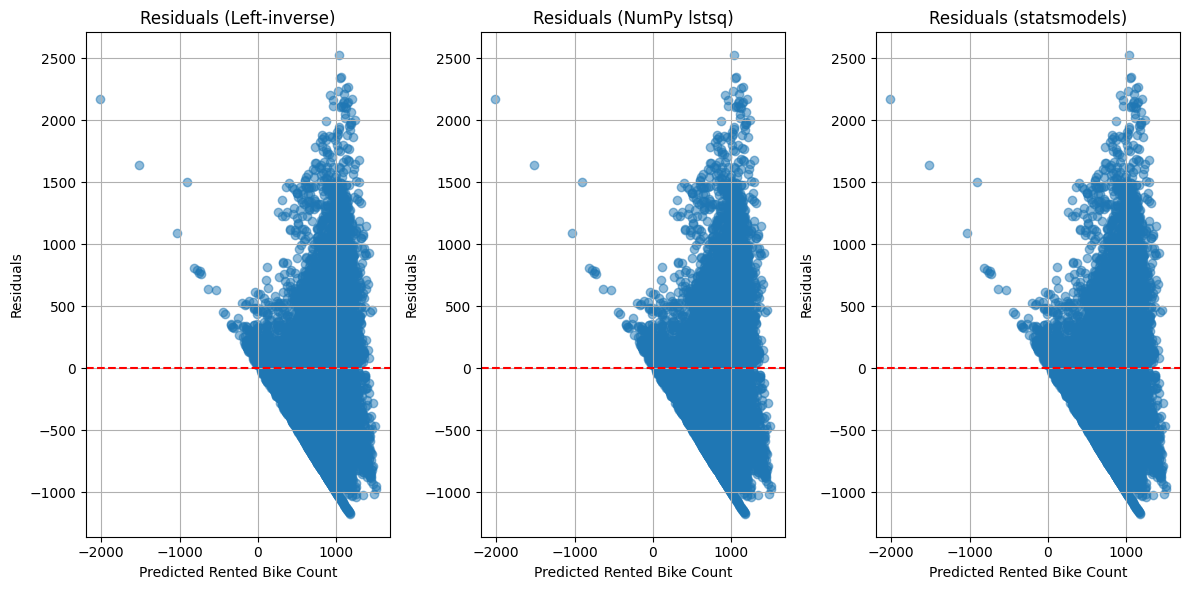

In [13]:
# Calculate residuals
residuals_leftinv = y - y_hat_leftinv
residuals_lstsq = y - y_hat_lstsq
residuals_statsmodels = y - model.predict(mat_temp_df).values.reshape(-1, 1)

# Plot residuals
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.scatter(y_hat_leftinv, residuals_leftinv, alpha=0.5)
plt.xlabel('Predicted Rented Bike Count')
plt.ylabel('Residuals')
plt.title('Residuals (Left-inverse)')
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.scatter(y_hat_lstsq, residuals_lstsq, alpha=0.5)
plt.xlabel('Predicted Rented Bike Count')
plt.ylabel('Residuals')
plt.title('Residuals (NumPy lstsq)')
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.scatter(model.predict(mat_temp_df), residuals_statsmodels, alpha=0.5)
plt.xlabel('Predicted Rented Bike Count')
plt.ylabel('Residuals')
plt.title('Residuals (statsmodels)')
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True)

plt.tight_layout()
plt.show()

### Regularization (Ridge Regression)

In [14]:
# Regularization strength
gamma = 0.01

# Compute scaled Frobenius norm squared of the matrix
gamma_norm = gamma * np.linalg.norm(mat_temp, 'fro') ** 2

# Inverse of (XᵀX + γI)
ridge_inv = np.linalg.inv(mat_temp.T @ mat_temp + gamma_norm * np.eye(mat_temp.shape[1]))

# Display inverse matrix properties
print(f"inv(XᵀX + {gamma}·I) size: {ridge_inv.shape}")
print(f"inv(XᵀX + {gamma}·I) rank: {np.linalg.matrix_rank(ridge_inv)}")

inv(XᵀX + 0.01·I) size: (4, 4)
inv(XᵀX + 0.01·I) rank: 4


In [15]:
# Range of regularization values
gamma_values = np.linspace(0, 0.2, 40)

# Initialize R2 arrays
r2_original = np.zeros_like(gamma_values)
r2_multicol = np.zeros_like(gamma_values)

# Loop over each gamma value
for i, g in enumerate(gamma_values):

    # Compute regularization parameter
    lam = g * np.linalg.norm(design_matrix, 'fro') ** 2

    # Compute regularized left-inverse
    leftinv = np.linalg.inv(design_matrix.T @ design_matrix + lam * np.eye(design_matrix.shape[1])) @ design_matrix.T

    # Compute model predictions
    beta = leftinv @ y
    y_hat = design_matrix @ beta

    # Compute model fit (R2)
    r2_original[i] = np.corrcoef(y.T, y_hat.T)[0, 1] ** 2

    # For Multicollinear
    lam_M = g * np.linalg.norm(mat_temp, 'fro') ** 2
    leftinv_M = np.linalg.inv(mat_temp.T @ mat_temp + lam_M * np.eye(mat_temp.shape[1])) @ mat_temp.T
    beta_M = leftinv_M @ y
    y_hat_M = mat_temp @ beta_M
    r2_multicol[i] = np.corrcoef(y.T, y_hat_M.T)[0, 1] ** 2

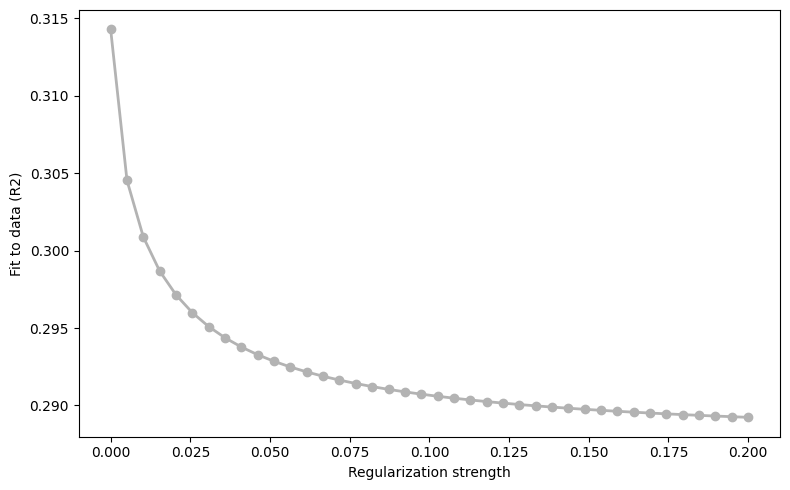

In [20]:
# Plot R2 across regularization values
plt.figure(figsize=(8, 5))
plt.plot(gamma_values, r2_multicol, 'o-', linewidth=2, color=[0.7, 0.7, 0.7])

# Labeling and aesthetics
plt.xlabel('Regularization strength')
plt.ylabel('Fit to data (R2)')
plt.tight_layout()
plt.show()

### Polynomial Regression

In [21]:
# data
year = [1534, 1737, 1803, 1928, 1960, 1975, 1987, 2023, 2057, 2100 ]
time = [ 697,  594,  260,  125,   76,   47,   37,   48,   70,  109 ]

N = len(year)

/tmp/ipython-input-3100148935.py:8: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(year, time, order)


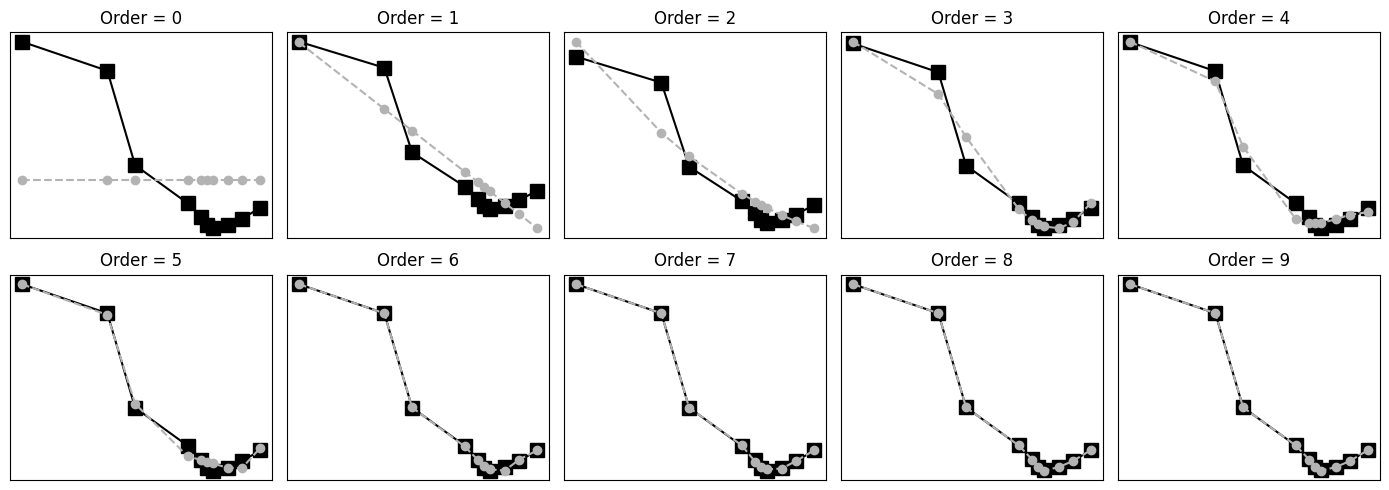

In [22]:
# Subplot grid (2 x 5)
fig, axs = plt.subplots(2, 5, figsize=(14, 5))
axs = axs.flatten()

# Loop over orders from 0 to N-1
for order in range(N):
    # Fit polynomial of given order
    coeffs = np.polyfit(year, time, order)
    y_hat = np.polyval(coeffs, year)

    # Plot data points and polynomial fit
    axs[order].plot(year, time, 'ks-', markersize=10, label='Data')
    axs[order].plot(year, y_hat, 'o--', color=[0.7, 0.7, 0.7], label='Fit')

    # Remove ticks for cleaner plots
    axs[order].set(xticks=[], yticks=[])

    # Title with polynomial order
    axs[order].set_title(f'Order = {order}')

plt.tight_layout()
plt.show()